In [6]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

In [7]:
california = fetch_california_housing()

In [8]:
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
param_distributions = {
    'iterations': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7],
    'l2_leaf_reg': [1, 3, 5, 9]
}

In [12]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV

In [13]:
random_state = 42

In [14]:
cb_base = CatBoostRegressor(random_state=random_state, verbose=1, thread_count=-1)
search = RandomizedSearchCV(
    cb_base, param_distributions, n_iter=10, 
    scoring='neg_root_mean_squared_error', cv=3, random_state=random_state
)

In [15]:
search.fit(X_train, y_train)

0:	learn: 1.0864812	total: 137ms	remaining: 13.5s
1:	learn: 1.0267817	total: 139ms	remaining: 6.8s
2:	learn: 0.9769689	total: 141ms	remaining: 4.55s
3:	learn: 0.9316315	total: 143ms	remaining: 3.43s
4:	learn: 0.8931510	total: 145ms	remaining: 2.75s
5:	learn: 0.8583942	total: 147ms	remaining: 2.3s
6:	learn: 0.8258744	total: 149ms	remaining: 1.98s
7:	learn: 0.7988029	total: 151ms	remaining: 1.74s
8:	learn: 0.7741332	total: 153ms	remaining: 1.55s
9:	learn: 0.7528702	total: 155ms	remaining: 1.4s
10:	learn: 0.7332202	total: 157ms	remaining: 1.27s
11:	learn: 0.7126473	total: 159ms	remaining: 1.17s
12:	learn: 0.6967069	total: 162ms	remaining: 1.08s
13:	learn: 0.6835309	total: 163ms	remaining: 1s
14:	learn: 0.6719567	total: 165ms	remaining: 936ms
15:	learn: 0.6617783	total: 167ms	remaining: 877ms
16:	learn: 0.6501468	total: 169ms	remaining: 826ms
17:	learn: 0.6416593	total: 171ms	remaining: 779ms
18:	learn: 0.6338719	total: 173ms	remaining: 737ms
19:	learn: 0.6234490	total: 175ms	remaining: 70

RandomizedSearchCV(cv=3,
                   estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=1),
                   param_distributions={'depth': [3, 5, 7],
                                        'iterations': [100, 300, 500],
                                        'l2_leaf_reg': [1, 3, 5, 9],
                                        'learning_rate': [0.01, 0.05, 0.1]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [16]:
best_model = search.best_estimator_

In [107]:
import shap
shap.initjs()

In [18]:
explainer = shap.TreeExplainer(best_model)

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_(x_grid, y_shape, x_data, feature_name, bins=30):
    fig, ax = plt.subplots(figsize=(6, 4))
    
    counts, bin_edges = np.histogram(x_data, bins=bins)
    max_count = counts.max()
    
    for i in range(len(counts)):
        alpha_val = (counts[i] / max_count) * 0.4 
        if alpha_val > 0:
            ax.axvspan(bin_edges[i], bin_edges[i+1], color='darkred', alpha=alpha_val, lw=0)
            
    ax.plot(x_grid, y_shape, color='royalblue', lw=3, label='Shape Function')
    
    ax.set_xlabel(feature_name, fontsize=12)
    ax.set_ylabel('Вклад в предсказание', fontsize=12)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(bin_edges[0], bin_edges[-1])
    
    plt.tight_layout()
    plt.show()

In [49]:
from sklearn.metrics import mean_squared_error
rmse_main = np.sqrt(mean_squared_error(y_test, best_model.predict(X_test)))
print(f"RMSE_test: {rmse_main:.4f}")

RMSE_test: 0.4610


In [64]:
shap_values = explainer.shap_values(X_train)
shap_interaction_values = explainer.shap_interaction_values(X_train)

In [101]:
shap_values

array([[-0.33533736,  0.11138371, -0.09368541, ...,  0.64102759,
         0.49742695,  0.09417443],
       [-0.01301509, -0.06083445, -0.06133942, ...,  0.02436481,
        -0.24729707,  0.13359209],
       [ 0.0795061 , -0.29903295,  0.09708298, ...,  0.41089363,
        -0.68785843, -0.19069338],
       ...,
       [-0.32613081,  0.01901313, -0.11967225, ...,  0.31686026,
         0.54295868, -0.15113776],
       [-0.40546718,  0.00526997, -0.10059264, ..., -0.26114302,
        -0.02058218,  0.77281282],
       [ 0.21422937,  0.01980636, -0.05793449, ...,  0.09388946,
        -0.35285407,  1.23937658]])

In [65]:
import numpy as np

In [66]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=X.columns).sort_values(ascending=False)
mean_abs_interactions = np.abs(shap_interaction_values).mean(axis=0)

print("Средние модули SHAP по признакам:")
print(shap_importance.to_string())
print()

interaction_df = pd.DataFrame(
    mean_abs_interactions,
    index=X.columns,
    columns=X.columns
)

triu_idx = np.triu_indices_from(interaction_df, k=1)
pairs = []
for i, j in zip(triu_idx[0], triu_idx[1]):
    pairs.append((X.columns[i], X.columns[j], mean_abs_interactions[i, j]))
pairs_df = pd.DataFrame(pairs, columns=['Признак 1', 'Признак 2', 'mean |SHAP interaction|'])
pairs_df = pairs_df.sort_values('mean |SHAP interaction|', ascending=False).reset_index(drop=True)
print("Топ-10 комбинаций признаков по mean |SHAP interaction|:")
print(pairs_df.head(10).to_string(index=False))

Средние модули SHAP по признакам:
Latitude      0.597531
Longitude     0.479237
MedInc        0.394780
AveOccup      0.198293
AveRooms      0.105138
HouseAge      0.048750
AveBedrms     0.026354
Population    0.023358

Топ-10 комбинаций признаков по mean |SHAP interaction|:
Признак 1 Признак 2  mean |SHAP interaction|
 Latitude Longitude                 0.231082
   MedInc  AveOccup                 0.032580
 HouseAge  AveOccup                 0.028774
 AveOccup  Latitude                 0.022728
   MedInc  AveRooms                 0.021733
   MedInc  HouseAge                 0.020848
   MedInc  Latitude                 0.020767
 AveOccup Longitude                 0.020494
   MedInc Longitude                 0.017965
 HouseAge  Latitude                 0.014099


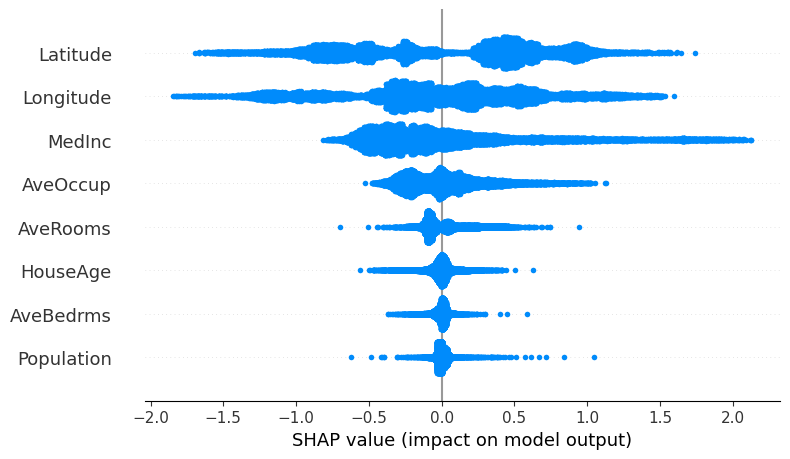

In [74]:
shap.summary_plot(shap_values=shap_values, feature_names=X.columns, show=False)

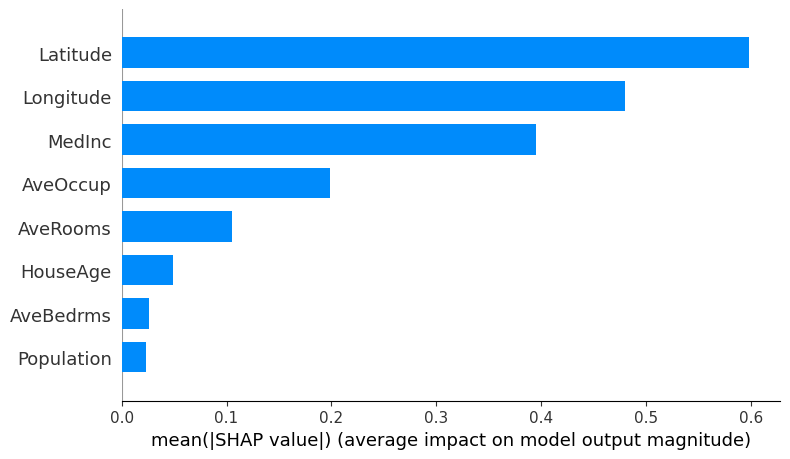

In [75]:
shap.summary_plot(shap_values=shap_values, plot_type="bar", feature_names=X.columns)

In [76]:
cb_stump = CatBoostRegressor(
    depth=1,
    iterations=500,
    learning_rate=0.01,
    l2_leaf_reg=1,
    random_state=random_state,
    verbose=1
)
cb_stump.fit(X_train, y_train)
print(f"RMSE: {np.sqrt(np.mean((cb_stump.predict(X_test) - y_test)**2)):.4f}")

0:	learn: 1.1526588	total: 1.01ms	remaining: 504ms
1:	learn: 1.1490694	total: 1.83ms	remaining: 455ms
2:	learn: 1.1456164	total: 2.57ms	remaining: 425ms
3:	learn: 1.1421348	total: 3.27ms	remaining: 405ms
4:	learn: 1.1386969	total: 3.93ms	remaining: 389ms
5:	learn: 1.1353488	total: 4.64ms	remaining: 382ms
6:	learn: 1.1320476	total: 5.47ms	remaining: 385ms
7:	learn: 1.1288069	total: 6.15ms	remaining: 379ms
8:	learn: 1.1256114	total: 7.05ms	remaining: 385ms
9:	learn: 1.1224894	total: 7.73ms	remaining: 379ms
10:	learn: 1.1193793	total: 8.75ms	remaining: 389ms
11:	learn: 1.1163110	total: 9.61ms	remaining: 391ms
12:	learn: 1.1132469	total: 10.4ms	remaining: 388ms
13:	learn: 1.1102498	total: 11ms	remaining: 382ms
14:	learn: 1.1072826	total: 11.7ms	remaining: 377ms
15:	learn: 1.1043918	total: 12.3ms	remaining: 372ms
16:	learn: 1.1015351	total: 12.9ms	remaining: 366ms
17:	learn: 1.0987509	total: 13.6ms	remaining: 365ms
18:	learn: 1.0959256	total: 14.3ms	remaining: 362ms
19:	learn: 1.0931601	tot

In [77]:
def get_shape_functions_from_stumps(model, X_df, feature_names, n_grid=200, percentiles=(1, 99)):

    X_median = X_df.median().values.reshape(1, -1)
    baseline = model.predict(X_median)[0]
    
    shape_functions = {}
    for i, feat in enumerate(feature_names):
        x_data = X_df[feat].values
        x_min, x_max = np.percentile(x_data, percentiles)
        x_grid = np.linspace(x_min, x_max, n_grid)
        
        X_eval = np.tile(X_median, (len(x_grid), 1))
        X_eval[:, i] = x_grid
        
        preds = model.predict(X_eval)
        f_i = preds - baseline
        f_i_centered = f_i - np.mean(f_i)
        
        shape_functions[feat] = {
            'x_grid': x_grid,
            'y_shape': f_i_centered,
            'x_data': x_data
        }
    return shape_functions

In [78]:
shape_funcs = get_shape_functions_from_stumps(cb_stump, X_train, list(X.columns))

In [79]:
import io
import json

In [81]:
import tempfile, os
with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
    tmp_path = f.name
cb_stump.save_model(tmp_path, format='json')
with open(tmp_path, 'r') as f:
    model_json = json.load(f)
os.unlink(tmp_path)
trees = model_json.get('oblivious_trees', model_json.get('tree_structures', []))

stumps_by_feature = {i: [] for i in range(len(X.columns))}
for tree in trees:
    splits = tree.get('splits', [])
    if len(splits) != 1:
        continue
    s = splits[0]
    if isinstance(s, dict) and 'split' in s:
        s = s['split']
    feat_idx = int(s.get('float_feature_index', s.get('split_index', 0)))
    border = float(s.get('border', 0))
    leaf_vals = tree.get('leaf_values', [0, 0])
    if len(leaf_vals) < 2:
        leaf_vals = [0, 0]
    stumps_by_feature[feat_idx].append({'border': border, 'left': leaf_vals[0], 'right': leaf_vals[1]})

for i, feat in enumerate(X.columns):
    print(f"{feat}: {len(stumps_by_feature[i])} деревьев (stumps)")

MedInc: 285 деревьев (stumps)
HouseAge: 13 деревьев (stumps)
AveRooms: 0 деревьев (stumps)
AveBedrms: 0 деревьев (stumps)
Population: 0 деревьев (stumps)
AveOccup: 112 деревьев (stumps)
Latitude: 60 деревьев (stumps)
Longitude: 30 деревьев (stumps)


In [82]:
n_top = 5
top_features = shap_importance.index[:n_top].tolist()

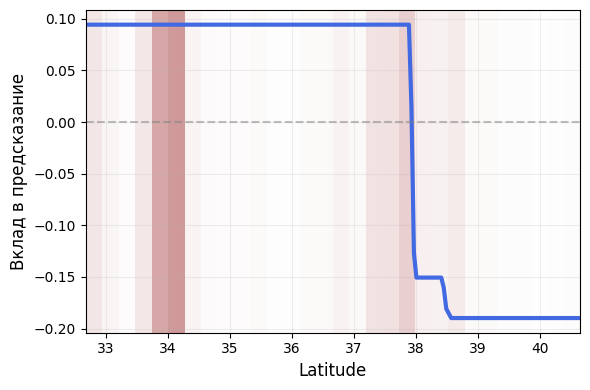

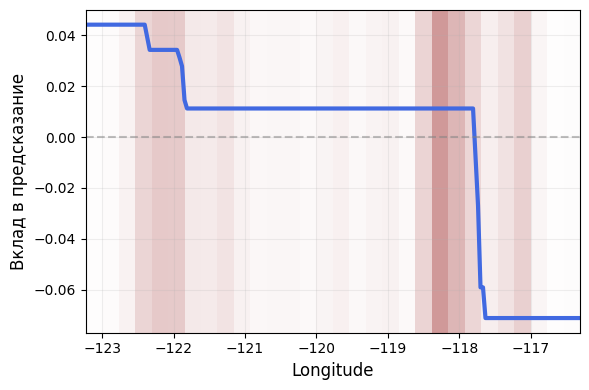

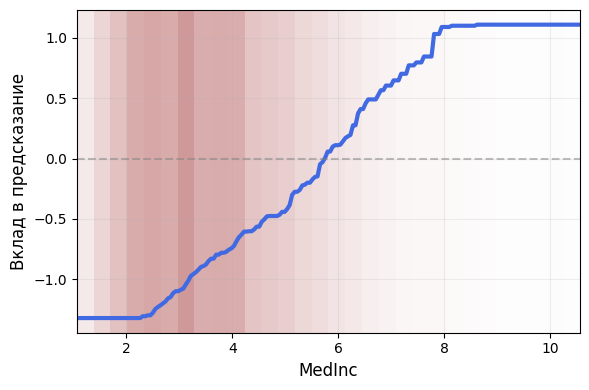

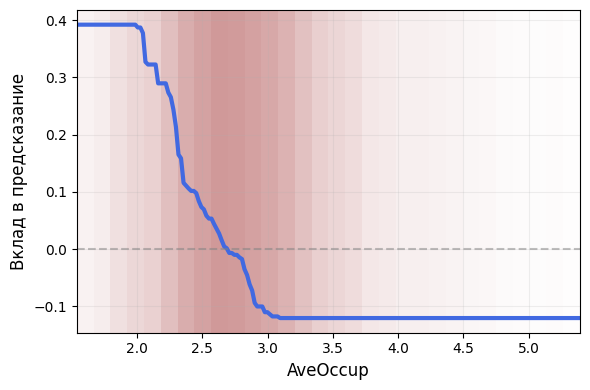

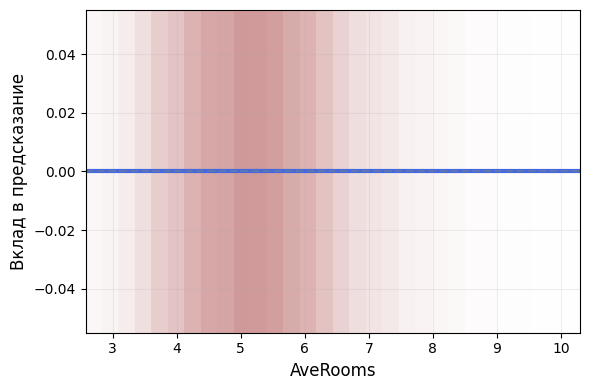

In [83]:
for feat_name in top_features:
    sf = shape_funcs[feat_name]
    x_grid = sf['x_grid']
    y_shape = sf['y_shape']
    x_data = sf['x_data']
    mask = (x_data >= x_grid.min()) & (x_data <= x_grid.max())
    plot_(x_grid, y_shape, x_data[mask], feat_name, bins=30)

In [84]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=X.columns).sort_values(ascending=False)

In [96]:
def get_shape_2d(model, X_df, feat1, feat2, n_grid=25, percentiles=(2, 98)):
    X_median = X_df.median().values
    i1, i2 = X_df.columns.get_loc(feat1), X_df.columns.get_loc(feat2)
    x1_min, x1_max = np.percentile(X_df[feat1], percentiles)
    x2_min, x2_max = np.percentile(X_df[feat2], percentiles)
    g1 = np.linspace(x1_min, x1_max, n_grid)
    g2 = np.linspace(x2_min, x2_max, n_grid)
    G1, G2 = np.meshgrid(g1, g2)
    
    X_eval = np.tile(X_median, (G1.size, 1))
    X_eval[:, i1] = G1.ravel()
    X_eval[:, i2] = G2.ravel()
    preds = model.predict(X_eval).reshape(G1.shape)
    return g1, g2, preds

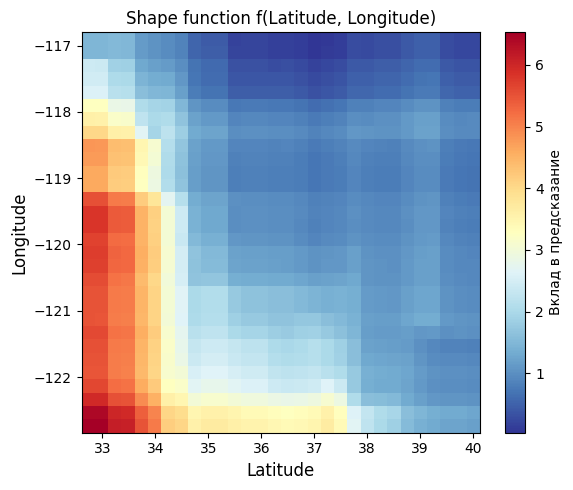

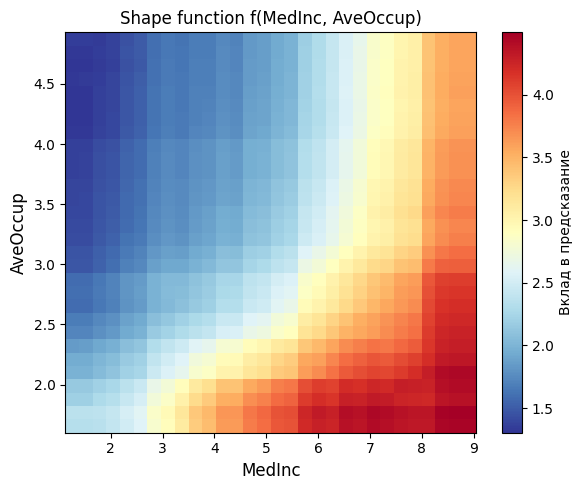

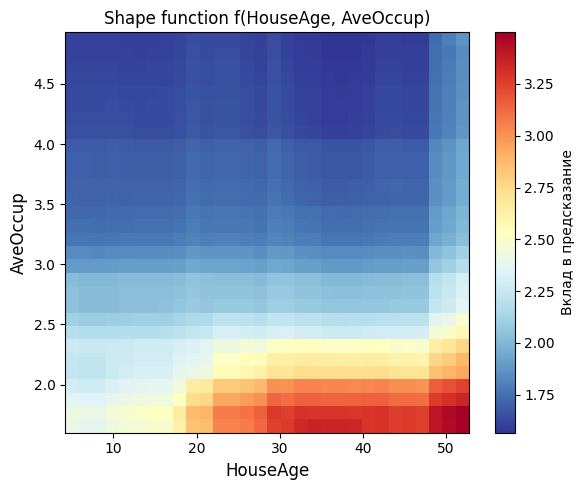

In [112]:
n_top_pairs = 3
top_pairs = list(zip(pairs_df['Признак 1'].head(n_top_pairs), pairs_df['Признак 2'].head(n_top_pairs)))
for f1, f2 in top_pairs:
    g1, g2, Z = get_shape_2d(best_model, X_train, f1, f2, n_grid=30)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.pcolormesh(g1, g2, Z, cmap='RdYlBu_r', shading='auto')
    ax.set_xlabel(f1, fontsize=12)
    ax.set_ylabel(f2, fontsize=12)
    ax.set_title(f'Shape function f({f1}, {f2})')
    plt.colorbar(im, ax=ax, label='Вклад в предсказание')
    plt.tight_layout()
    plt.show()

In [98]:
def get_shape_3d(model, X_df, feat1, feat2, feat3, n_grid=12, percentiles=(5, 95)):
    X_median = X_df.median().values
    i1 = X_df.columns.get_loc(feat1)
    i2 = X_df.columns.get_loc(feat2)
    i3 = X_df.columns.get_loc(feat3)
    
    g1 = np.linspace(*np.percentile(X_df[feat1], percentiles), n_grid)
    g2 = np.linspace(*np.percentile(X_df[feat2], percentiles), n_grid)
    g3 = np.linspace(*np.percentile(X_df[feat3], percentiles), n_grid)
    
    G1, G2, G3 = np.meshgrid(g1, g2, g3, indexing='ij')
    X_eval = np.tile(X_median, (G1.size, 1))
    X_eval[:, i1] = G1.ravel()
    X_eval[:, i2] = G2.ravel()
    X_eval[:, i3] = G3.ravel()
    preds = model.predict(X_eval)
    return G1.ravel(), G2.ravel(), G3.ravel(), preds

In [113]:
from mpl_toolkits.mplot3d import Axes3D


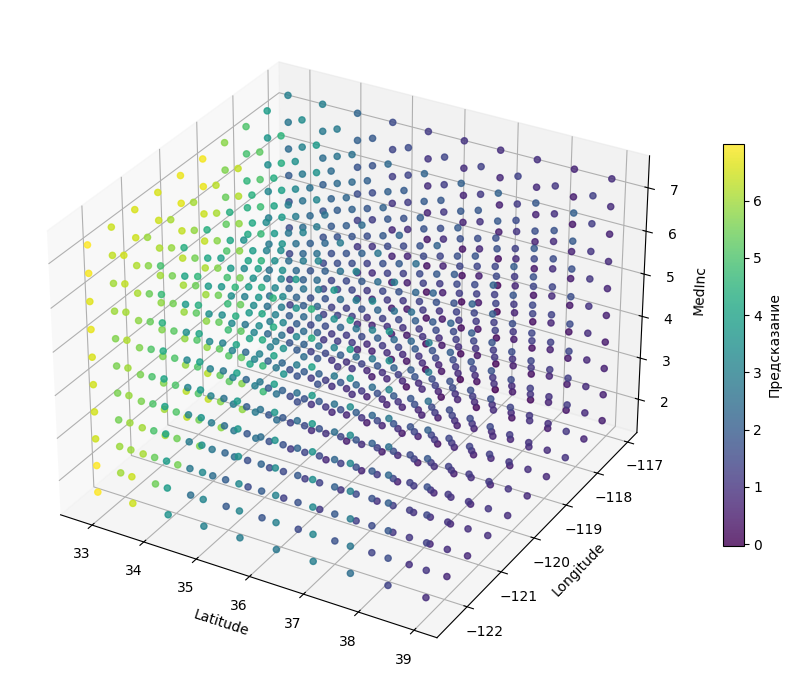

In [114]:
top3 = ['Latitude', 'Longitude', 'MedInc']
x1, x2, x3, vals = get_shape_3d(best_model, X_train, *top3, n_grid=10)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x1, x2, x3, c=vals, s=20, alpha=0.8)
ax.set_xlabel(top3[0])
ax.set_ylabel(top3[1])
ax.set_zlabel(top3[2])
plt.colorbar(sc, ax=ax, label='Предсказание', shrink=0.6)
plt.tight_layout()
plt.show()

In [100]:
shap_importance

Latitude      0.597531
Longitude     0.479237
MedInc        0.394780
AveOccup      0.198293
AveRooms      0.105138
HouseAge      0.048750
AveBedrms     0.026354
Population    0.023358
dtype: float64